In [ ]:
# import pandas as pd
# df = pd.read_csv('papermodeldata(in).csv')
# len(df.columns) -5 

# df['ttd'].isnull().any()
# df['fold'].isnull().any()
# df['time'].isnull().any()
# df['y'].isnull().any()

# df['VitalID'].groupby(df['VitalID']).count()
# df_dead = df[df['y'] == 1]
# df_alive = df[df['y'] == 0]

# df_alive['VitalID'].groupby(df_alive['VitalID']).count()

In [2]:
import scipy.io
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import pickle as pl
from collections import OrderedDict
import traceback
import random
import threading

### Creating the Patient data from the samples data and the vitals metadata 

In [ ]:
# The sample data doesnt have any useful things

In [3]:
# pname and pdata are metadata of the patient id 
# v data and v name are the vitals and the values
mat_file = scipy.io.loadmat('/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/NICU_1005_vitals.mat')
columns= [str(i[0]) for i in list(mat_file['pname'].reshape(-1))]

In [11]:
columns

['PatientID',
 'BirthTime',
 'BirthWeight',
 'GestAge',
 'GestAgeDays',
 'Male',
 'APGAR1',
 'APGAR5',
 'APGAR10',
 'Age at Death']

In [10]:
mat_file['pdata'][0][3]

np.float64(24.0)

In [12]:
mat_file['pdata'][0][4]

np.float64(6.0)

In [ ]:
mat_files = glob.glob('/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/*.mat')
dataframes = [ pd.DataFrame(scipy.io.loadmat(file)['pdata'],columns=columns) for file in mat_files]

In [ ]:
metadata_df = pd.concat(dataframes,ignore_index=True)

In [ ]:
metadata_df = metadata_df.rename(columns={'PatientID': 'id'})

In [ ]:
final_df = pd.merge(vitals_combined_df, metadata_df, on='id', how='left')

In [ ]:
list(final_df.columns)

In [ ]:
final_df.to_pickle('final_df.pkl')

In [ ]:
final_df['id'].value_counts()

In [ ]:
# import multiprocessing as mp
# from multiprocessing import Pool
# def process_file(filename):
#     df = pd.read_csv(filename)
#     """Function to process a single file"""
#     print(df.value_counts())

In [ ]:
# 5,998 patients but metrics only for 5957 in the samples
# The time is not during one day but is actually distributed across multiple days in the samples and the vitals
# is the data in samples random ? 
# the vnames in the vitals dont match the ones in the sample (the features in the sample are not in the vitals)

### creating the patient data from the vitals data and metadata

In [3]:
mat_file = scipy.io.loadmat('/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/NICU_1007_vitals.mat')

In [4]:
names = mat_file['vname'].flatten()

In [5]:
names # just focus on HR and SPo2

array([array(['HR'], dtype='<U2'), array(['RESP'], dtype='<U4'),
       array(['SPO2-%'], dtype='<U6'), array(['SPO2-R'], dtype='<U6'),
       array(['PT-RR'], dtype='<U5'), array(['NBP-S'], dtype='<U5'),
       array(['NBP-D'], dtype='<U5'), array(['NBP-M'], dtype='<U5')],
      dtype=object)

In [6]:
data = mat_file['vdata']

In [7]:
data.shape

(6107204, 8)

In [8]:
data[:,0].flatten()

array([ nan,  nan,  nan, ..., 152., 150., 150.], shape=(6107204,))

In [9]:
mat_file['pname']

array([[array(['PatientID'], dtype='<U9')],
       [array(['BirthTime'], dtype='<U9')],
       [array(['BirthWeight'], dtype='<U11')],
       [array(['GestAge'], dtype='<U7')],
       [array(['GestAgeDays'], dtype='<U11')],
       [array(['Male'], dtype='<U4')],
       [array(['APGAR1'], dtype='<U6')],
       [array(['APGAR5'], dtype='<U6')],
       [array(['APGAR10'], dtype='<U7')],
       [array(['Age at Death'], dtype='<U12')]], dtype=object)

In [10]:
mat_file['pdata']

array([[1.007e+03, 7.680e+04, 3.600e+02, 2.400e+01, 5.000e+00, 0.000e+00,
        6.000e+00, 6.000e+00, 7.000e+00,       nan]])

In [ ]:
# Question:
# see the null and non-null distribution of 
# id column and the data columns
# (to validate if hr and spo2 are only important) across all mat files

# Analysis:
# Seeing how many null values are there

In [ ]:
# # to see distribution and null percentage of one mat file
# for i in range(data.shape[1]):
#     plt.subplot(1, 3, 1)
#     plt.hist(data[:,i].flatten(), bins=50, alpha=0.7)
#     plt.title(f'{names[i]}')
#     plt.ylabel('Frequency')
#     plt.tight_layout()
#     plt.show()
    
print("Null values in data columns:")
for i in range(data.shape[1]):
    null_count = np.isnan(data[:, i]).sum()
    total_count = len(data[:, i])
    print(f"{names[i]}: {null_count} nulls out of {total_count} ({null_count/total_count*100:.1f}%)")

In [ ]:
# Question: 
# see the null and non-null distribution of time_columns values 

# Analysis:
# some values are negative 
# the seconds don't start from (aka measurement doesnt start from midnigt when the baby is born)
# the frequency of measurements within intervals were erratic 

In [ ]:
times = mat_file['vt']

In [ ]:
age_at_death_arr = [scipy.io.loadmat(file)['pdata'][0][-1] for file in mat_files]

In [ ]:
mat_files = glob.glob('/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/*.mat')
arr = [scipy.io.loadmat(file)['vt'].reshape(-1) for file in mat_files]

see the no of files which perish  <br>
see the no of files which do not perish 

In [ ]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/age_at_death','rb') as f:
    arr = pl.load(f)

In [ ]:
print("Total Count: " + str(len(arr)))
nan_count = np.isnan(arr).sum()
print(f"Non-NICU count: {nan_count}")
print(f"NICU count: {len(arr)-nan_count}")

In [ ]:
indicator_vector = []
for i in arr:
    if(np.isnan(i)):
        indicator_vector.append(0)
    else:
        indicator_vector.append(1)
    

In [ ]:
with open('indicator_vector.pkl', 'wb') as f:
    pl.dump(indicator_vector, f)

In [ ]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/arr_context_size.pkl','rb') as f:
    arr_context_size = pl.load(f)

In [ ]:
arr_context_size_nicu = []
arr_context_size_nonnicu = []

for i in range(len(indicator_vector)) :
    if(indicator_vector[i]==0):
        arr_context_size_nonnicu.append(arr_context_size[i])
    else:
        arr_context_size_nicu.append(arr_context_size[i])

In [ ]:
# seeing the distribution of the values 
plt.hist(arr_context_size_nicu , bins=10, edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of Values')
plt.xlim(0, 3.5e+7) 
plt.grid(True)
plt.show()

In [ ]:
# within every 5 minute interval after 0 and until ttd, how many datapoints are complete.(100% window coverage)(atleast one valid datapoint in every window)
# within every 5 minutes interval after first observation , and until the last observation, how many datapoints are complete(100% window coverage)(atleast one valid datapoint in every window)

# the ttd is not given and from the readme, it seems the last observation doesnt coincide the ttd..but first we need to find the first ttd
# np.float64(0.9524762381190596) of the datapoitns have there ageatdeath as NaN

In [ ]:
# What wre we lloking for ? one of the two options?is it till startobserv,last observ or 0,ttd
# what is a valid datapoint for us ? do we include resp as well along with the cols we think?

In [ ]:
# x1,y1
# x2,y2
# sum(totalx,totaly)

## Real stuff

In [ ]:
# timestamps: [2,3,5],  hr[null, 3, null]  spo2[null,2,3]
# timestamps - take min and max 
# distribute it step size = 2 
# copy voer the valid values for the timestamps 
# do the analaysis for per 5 time windows (misses,hits,noofwindows)

# store the true, false arrays in pickle files
# hits,no of windows  for this particular window size
# one row for each baby for a particular window size
# cols would be window sizes.

# do this for every baby 

In [ ]:
# take the hr values and see which are non null 
# take the sp2 values and see which are non null 
# do the and to find the values which have non-null hr and sp02
# store this and the timestamps array

# for wsize in sizes:
#   for baby in babies:
        # timestamp is sorted array
        # the first window starts from the first timestamp
        # see if the next value is in the current window, if yes, assign the window a hit
        # see if the next value is in the next window, increment the counter to see the next window by the window size
        # else, see how many middle windows we have missed 
        # append the (no of misses, hits, and total no of windows)

In [ ]:
# take the start and end timestamp to figure out the no of windows

# you only need the timestamp info to be stored later to compute for arbitary window sizes
# since you can just take the timestamp with corresponding true in final_arr
# basiclaly in order to sae compute jsut assign those invalid timestamps to be null

# after getting those valid timestamps, you then iterate through the timestamps and then group timestamps in one window to one timestamp
# start with a timestamp, icnrement the counter
# if timestamp!=null
# see if the next is within the 300 s and skip it 
# once you find one which is not, windowsize - (timestamp - 300*(timestamp-orig)/300)), increment the counter 
# see if the next one is within that range and skip it 

# we have the no of hits, then we have the no of windows, no of misses = no of windows - no of hits

In [ ]:
# we are starting the measurement from a valid timestamp since we need to know where to start the window strides. 

In [ ]:
# assumign timestamps are non-null and sorted

In [ ]:
# 20,000 datapoints 
# s , t
# w
# 

In [16]:
mat_data = scipy.io.loadmat('/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/NICU_7722_vitals.mat')

In [17]:
mat_data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Thu Dec 17 12:42:55 2020',
 '__version__': '1.0',
 '__globals__': [],
 'pdata': array([[7.722e+03, 2.790e+04, 3.590e+03, 3.900e+01, 5.000e+00, 1.000e+00,
         4.000e+00, 1.000e+00, 6.000e+00,       nan]]),
 'pname': array([[array(['PatientID'], dtype='<U9')],
        [array(['BirthTime'], dtype='<U9')],
        [array(['BirthWeight'], dtype='<U11')],
        [array(['GestAge'], dtype='<U7')],
        [array(['GestAgeDays'], dtype='<U11')],
        [array(['Male'], dtype='<U4')],
        [array(['APGAR1'], dtype='<U6')],
        [array(['APGAR5'], dtype='<U6')],
        [array(['APGAR10'], dtype='<U7')],
        [array(['Age at Death'], dtype='<U12')]], dtype=object),
 'vdata': array([[148.,  59.,  nan, ...,  nan,  nan,  nan],
        [148.,  53.,  nan, ...,  nan,  nan,  nan],
        [148.,  47.,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  94., ...,  nan,  nan,  nan],
        [ nan,  nan,  nan

In [ ]:
bool1 = mat_data['vname'][0][0][0] == 'HR'
bool2 = mat_data['vname'][2][0][0] == 'SPO2-%'
print(bool1 and bool2)

In [ ]:
# code to check for whether the vname can be hardcoded or not
mat_files = sorted(glob.glob('/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/*.mat'))
false_num = 0
for i, file_path in enumerate(mat_files):
        mat_data = scipy.io.loadmat(file_path)
        
        try:
             bool1 = mat_data['vname'][0][0][0] == 'HR'
             bool2 = mat_data['vname'][2][0][0] == 'SPO2-%'
        
        except:
             print(file_path)
             print(mat_data['vname'])
                
        final_bool = bool1 and bool2
        if not(final_bool):
                false_num+=1
                

In [ ]:
# code to check for whether the vname can be hardcoded or not
mat_files = sorted(glob.glob('/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/*.mat'))
false_num = 0
for i, file_path in enumerate(mat_files):
        mat_data = scipy.io.loadmat(file_path)
        
        try:
             bool1 = mat_data['vname'][0][0][0] == 'HR'
             bool2 = mat_data['vname'][2][0][0] == 'SPO2-%'
        
        except:
             print(file_path)
             print(mat_data['vname'])
                
        final_bool = bool1 and bool2
        if not(final_bool):
                false_num+=1

In [23]:
import scipy.io
import numpy as np
import pandas as pd
import glob
import math

mat_files = sorted(glob.glob('/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/*.mat'))

# # Collect values
# age_at_death_values = []
# birth_time_values = []

no_of_null = 0
for file_path in mat_files[:50]:
    mat_data = scipy.io.loadmat(file_path)
    age_at_death = mat_data['pdata'][0][9]
    if ( math.isnan(age_at_death)):
        no_of_null+=1
        
    
    
    
    # age_at_death_values.append(mat_data['pdata'][0][9])
    # birth_time_values.append(mat_data['pdata'][0][1])


# # Print summary
# print(f"{'='*70}")
# print(f"Total files: {len(mat_files)}")
# print(f"{'='*70}\n")

# print("Age at Death:")
# print(f"  Null:     {age_at_death.isna().sum():>5} ({age_at_death.isna().mean()*100:>6.2f}%)")
# print(f"  Non-null: {age_at_death.notna().sum():>5} ({age_at_death.notna().mean()*100:>6.2f}%)\n")

# print("Birth Time:")
# print(f"  Null:     {birth_time.isna().sum():>5} ({birth_time.isna().mean()*100:>6.2f}%)")
# print(f"  Non-null: {birth_time.notna().sum():>5} ({birth_time.notna().mean()*100:>6.2f}%)\n")

# print(f"{'='*70}")
# print("Age at Death (non-null) stats:")
# print(age_at_death.dropna().describe())

# print(f"\nBirth Time stats:")
# print(birth_time.dropna().describe())

In [ ]:
# mat_data = scipy.io.loadmat('/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/NICU_1169_vitals.mat')

# # Find HR and SPO2 columns
# hr_cols = mat_data['vdata'][:,0]
# spo2_cols = mat_data['vdata'][:,2]
# valid_timestamps = mat_data['vt']

# # Step 1: Filter for non-null HR and SPO2 values
# final_arr = ~np.isnan(hr_cols) & ~np.isnan(spo2_cols)

In [ ]:
# 1,2,4,15,20
# wsize =7

# 0,7
# 7-14
# 14-21

In [ ]:
def analyze_coverage_non_optimal(all_timestamps, results, wsize, final_arr):
    """
    Analyze window coverage for a specific window size
    """
    # Filter for valid timestamps only (where final_arr is True)
    valid_timestamps = all_timestamps[final_arr]
    
    # record_timestamps = []


    # Define the overall time range (from first to last timestamp in ALL data)
    first_overall = all_timestamps[0].item()
    last_overall = all_timestamps[-1].item()
    
    # Calculate total number of windows
    total_duration = last_overall - first_overall
    total_windows = int(np.floor(total_duration / wsize))  + 1
    
    if len(valid_timestamps) == 0:
        results[wsize] = {
            'hits': 0,
            'misses': total_windows, 
            'total_windows': total_windows,
            'coverage_rate': 0
        }
        return
    

    
    hits = 0
    
    # Iterate through each possible window
    for window_idx in range(total_windows):
        # Define current window boundaries
        window_start = first_overall + (window_idx * wsize)
        window_end = window_start + wsize
        
        # Check if any valid timestamps fall within this window
        timestamps_in_window = valid_timestamps[
            (valid_timestamps >= window_start) & 
            (valid_timestamps < window_end)
        ]
        
        # timestamps_in_window = list(timestamps_in_window.reshape(-1))
        
        # If there's at least one valid timestamp in this window, it's a hit
        if len(timestamps_in_window) > 0:
            # record_timestamps.append(timestamps_in_window[0])
            hits += 1
    
    # Calculate misses
    misses = total_windows - hits
    
    results[wsize] = {
        'hits': hits,
        'misses': misses, 
        'total_windows': total_windows,
        'coverage_rate': hits / total_windows if total_windows > 0 else 0
    }
    
    # return list(record_timestamps)

In [ ]:
def analyze_coverage_vectorized(all_timestamps, results, wsize, final_arr):
    """
    Vectorized version - faster for large datasets
    """
    valid_timestamps = all_timestamps[final_arr]
    total_duration = all_timestamps[-1] - all_timestamps[0]
    total_windows = int(np.floor(total_duration / wsize))  + 1
    
    # record_timestamps = []
        
        
    if len(valid_timestamps) == 0:
        results[wsize] = {
            'hits': 0, 
            'misses': total_windows, 
            'total_windows': total_windows,
            'coverage_rate': 0
        }
        return
    
    first_overall = all_timestamps[0].item()
    last_overall = all_timestamps[-1].item()
    
    # Vectorized approach: assign each timestamp to a window
    window_indices = np.floor((valid_timestamps - first_overall) / wsize).astype(int)
    
    # Count unique windows that have at least one timestamp
    unique_windows = np.unique(window_indices)
    hits = len(unique_windows)
    
    # window_indices_list = list(window_indices)
    
    # temp_indice = window_indices_list[0]
    # record_timestamps = [temp_indice]
    # for i in range(len(window_indices_list)):
    #     if window_indices_list[i]==temp_indice:
    #         continue
    #     else:
    #         record_timestamps.append(i)
    #         temp_indice  = window_indices_list[i]
    
    # for i in range(len(record_timestamps)):
    #     record_timestamps[i] = int(valid_timestamps[record_timestamps[i]])
        
    
    misses = total_windows - hits
    
    results[wsize] = {
        'hits': hits,
        'misses': misses,
        'total_windows': total_windows,
        'coverage_rate': hits / total_windows if total_windows > 0 else 0
    }

    # return list(record_timestamps)

In [ ]:
# def analyze_coverage(all_timestamps, results, wsize, final_arr):
#     """
#     Analyze window coverage for a specific window size
#     """

#     # Filter for valid timestamps only (where final_arr is True)
#     valid_timestamps = all_timestamps[final_arr]
#     # print("No of valid timestamps: " + str(len(valid_timestamps)))
    
#     # Calculate total number of windows from first to last timestamp
#     total_duration = all_timestamps[-1] - all_timestamps[0]
#     total_windows = int(np.ceil(total_duration / wsize)) 
    
#     if(len(valid_timestamps)==0):
#         results[wsize] = {
#             'hits': 0,
#             'misses': total_windows, 
#             'total_windows': total_windows,
#             'coverage_rate': 0
#         }
#         return
    
#     # Start and end timestamps
#     first_time = valid_timestamps[0].item()
#     last_time = valid_timestamps[-1].item()
    
#     hits = 1
#     current_window_start = first_time
#     data_index = 0
#     gap_seconds = wsize
    
#     # Iterate through each window
#     while data_index< len(valid_timestamps):
#         # print(f"Gap Seconds: {type(gap_seconds)}")
#         # print("CurrentIndex: " + str(data_index))
#         window_end = current_window_start + gap_seconds
#         # print(f"Window end: {type(window_end)}")
#         # print(f"current interval: {type(current_window_start)}-{type(window_end)} (not including)")
        
#         # Find datapoints in current window
#         while (data_index < len(valid_timestamps) and valid_timestamps[data_index] < window_end):
#             data_index += 1

#         # Check if there's data in current window
#         if (data_index < len(valid_timestamps)):
#             # print("Nexttimestamp: " + str(valid_timestamps[data_index]))
#             next_timestamp = valid_timestamps[data_index].item()
#             current_window_start = next_timestamp
#             gap_seconds = wsize - (next_timestamp - (  wsize * ((next_timestamp- first_time +1)//wsize) + first_time )  )  
#             # print("gap seconds: " + str(gap_seconds))    
#             data_index += 1
#             hits += 1
            
#         print("\n")
    
#     # Calculate misses
#     misses = total_windows - hits
    
#     results[wsize] = {
#         'hits': hits,
#         'misses': misses, 
#         'total_windows': total_windows,
#         'coverage_rate': hits / total_windows if total_windows > 0 else 0
#     }

In [ ]:
def analyze_baby_window_coverage(mat_file_path, window_sizes,optimized,context_size):
    """
    Analyze window coverage for a single baby across different window sizes
    """
    # Load mat file
    mat_data = scipy.io.loadmat(mat_file_path)
    vname = mat_data['vname']
    
    if 'HR' in vname and 'SPO2-%' in vname:
        if (vname[0][0][0] == 'HR') and (vname[2][0][0] == 'SPO2-%'): 
            hr_cols = mat_data['vdata'][:,0]
            spo2_cols = mat_data['vdata'][:,2]
        else:
            hr_cols = mat_data['vdata'][:,vname.index('HR')]
            spo2_cols = mat_data['vdata'][:,vname.index('SPO2-%')]
    else:
        raise Exception(f"{mat_file_path}: File does not have HR or SPO2")
    
    valid_timestamps = mat_data['vt']
    
    # Step 1: Filter for non-null HR and SPO2 values
    final_arr = ~np.isnan(hr_cols) & ~np.isnan(spo2_cols)
    
    # Step 2: Analyze for each window size
    results = {}
    for wsize in window_sizes:
        # print(f"Analyzing for {mat_file_path}")
        # print(f" - analyzing for window size: {wsize}")
        
        if(optimized):
            analyze_coverage_vectorized(valid_timestamps, results, wsize, final_arr)
            # return analyze_coverage_vectorized(valid_timestamps, results, wsize, final_arr)
            
        else:
            analyze_coverage_non_optimal(valid_timestamps, results, wsize, final_arr)
            # analyze_coverage(valid_timestamps,results,wsize,final_arr)
            # return analyze_coverage_non_optimal(valid_timestamps, results, wsize, final_arr)
    
    return results

In [ ]:
def save_results_to_pickle(summary_df, baby_results, window_sizes,filename):
    """Save results to pickle file"""
    results_dict = {
        'summary_df': summary_df,
        'baby_results': baby_results,
        'window_sizes': window_sizes
    }
    
    with open(filename, 'wb') as f:
        pl.dump(results_dict, f)
    
    print(f"Results saved to {filename}")

In [ ]:
def analyze_all_babies_windows(window_sizes,mat_files,optimized,filename,context_size):
    """
    Analyze window coverage for all babies across different window sizes
    """
    
    # Store results for each baby and window size
    all_results = []
    baby_results = {}
    
    print(f"Analyzing {len(mat_files)} babies with window sizes: {window_sizes}")
    
    for i, file_path in enumerate(mat_files):
        print(f"\nProcessing baby {i+1}/{len(mat_files)}: {file_path}")
        
        try:
            # Analyze this baby
            baby_result = analyze_baby_window_coverage(file_path, window_sizes,optimized,context_size)
            
        except:
            traceback.print_exc()
            continue
            
        baby_id = file_path.split('/')[-1]  # Extract filename as baby ID
        baby_results[baby_id] = baby_result
        
        # Create a row for summary DataFrame
        row = OrderedDict()
        row['baby_id'] = baby_id
        for wsize in window_sizes:
            row[f'coverage_{wsize}s'] = baby_result[wsize]['coverage_rate']
            row[f'hits_{wsize}s'] = baby_result[wsize]['hits']
            row[f'total_windows_{wsize}s'] = baby_result[wsize]['total_windows']
        
        all_results.append(row)
        
        if(i%60==0):
            save_results_to_pickle(pd.DataFrame(all_results), baby_results,window_sizes, filename=filename)
                    
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(all_results)
    
    return summary_df, baby_results

In [ ]:
# Define window sizes (in seconds)
window_sizes = [60,120,180,300,600]  # 1min, 2min, 3min, 5min, 10min,

# Get all mat files

# mat_files = sorted(glob.glob('/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/*.mat'))

mat_files = glob.glob('/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/*.mat')
# random.shuffle(mat_files)
# mat_files = mat_files[:1000]

In [ ]:
filename = 'vectorized.pkl'
summary_df, baby_results = analyze_all_babies_windows(window_sizes,mat_files,True,filename,None)
save_results_to_pickle(summary_df, baby_results,window_sizes, filename=filename)

In [ ]:
filename = 'results_non_optimal_1.pkl'
summary_df, baby_results = analyze_all_babies_windows(window_sizes,mat_files,False,filename,None)
save_results_to_pickle(summary_df, baby_results,window_sizes, filename=filename)

In [ ]:
def run_non_optimal_analysis():
    """Thread function for non-optimal analysis"""
    filename = 'results_non_optimal_1.pkl'
    print("Starting non-optimal analysis...")
    summary_df, baby_results = analyze_all_babies_windows(window_sizes, mat_files, False, filename)
    save_results_to_pickle(summary_df, baby_results, window_sizes, filename=filename)
    print("Non-optimal analysis completed!")

def run_vectorized_analysis():
    """Thread function for vectorized analysis"""
    filename = 'results_vectorized_1.pkl'
    print("Starting vectorized analysis...")
    summary_df, baby_results = analyze_all_babies_windows(window_sizes, mat_files, True, filename)
    save_results_to_pickle(summary_df, baby_results, window_sizes, filename=filename)
    print("Vectorized analysis completed!")

# Create threads
thread_non_optimal = threading.Thread(target=run_non_optimal_analysis)
thread_vectorized = threading.Thread(target=run_vectorized_analysis)

# Start both threads
print("Starting both analyses concurrently...")
thread_non_optimal.start()
thread_vectorized.start()

# Wait for both to complete
thread_non_optimal.join()
thread_vectorized.join()

print("Both analyses completed!")

### Analysing the dataframe

In [ ]:
mat_data = scipy.io.loadmat('/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/NICU_1015_vitals.mat')

In [ ]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/results_non_optimal_fixed.pkl','rb') as f:
    dic = pl.load(f)
summary_df_non_optimal_fixed = dic['summary_df']

In [ ]:
l1 = np.array(list(summary_df_non_optimal_fixed['baby_id']))

In [ ]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/results_vectorized.pkl','rb') as f:
    dic = pl.load(f)
summary_df_vectorized = dic['summary_df']

In [ ]:
l2 = np.array(list(summary_df_vectorized['baby_id']))[:582]

In [ ]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/results_vectorized_fixed.pkl','rb') as f:
    dic = pl.load(f)
summary_df_vectorized_correct = dic['summary_df']

In [ ]:
summary_df = dic['summary_df']

In [ ]:
columns = summary_df.columns

In [ ]:
boolean_arr = ["coverage" in col for col in columns]
coverage_columns = columns[boolean_arr]

In [ ]:
# seeing the line plot of the hit rates for different window sizes
x = [i for i in range(len(summary_df))]
for i in coverage_columns:
    plt.plot(x,list(summary_df[i]), color='blue',linestyle='dotted',linewidth=0.1)
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.title('Multiple Lines on a Single Plot')
    plt.legend() # Display the legend with labels
    # Show the plot
    plt.show()

In [ ]:
# seeing the distribution of the hit rate for different window sizes
for i in coverage_columns:
    plt.hist(list(summary_df[i]), bins=30, edgecolor='black')
    plt.grid()
    plt.show()

In [ ]:
bug_arr = np.array(summary_df[coverage_columns[-1]])>1

In [ ]:
summary_df[coverage_columns[-1]][bug_arr]

In [ ]:
summary_df.loc[5183]['coverage_60s']

In [ ]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/window_analysis.pkl','rb') as f:
    dic_bug = pl.load(f)

In [ ]:
dic_bug['summary_df']

## Checking vectorized vs non_optimal

In [ ]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/results_non_optimal_1.pkl','rb') as f:
    df_non_optimal = pl.load(f)['summary_df']

In [ ]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/results_vectorized_1.pkl','rb') as f:
    df_vectorized = pl.load(f)['summary_df']

In [ ]:
df_bool = df_non_optimal != df_vectorized 

In [ ]:
indices = set()
for i in df_bool.columns:
    liste = list(df_bool.loc[:,i])
    for i in range(len(liste)):
        if (liste[i]):
            indices.add(i) 

In [ ]:
indices

In [ ]:
# NICU_7649_vitals.mat   168
# NICU_6392_vitals.mat   290
# NICU_6706_vitals.mat   597
# NICU_4926_vitals.mat   666

In [ ]:
for index in indices:
    print(df_non_optimal.iloc[index,:])
    print("\n")
    print(df_vectorized.iloc[index,:])
    print("\n\n")

In [ ]:
# indexes, filenames, keep track of the different timestamps which generated thos ehits and compare

In [ ]:
window_sizes = [300]
for indice in indices:
    file_name = '/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/' + df_non_optimal.iloc[indice,0]
    print(indice)
    print(file_name)    
    l2 = set(analyze_baby_window_coverage(file_name,window_sizes,False))
    l1 = set(analyze_baby_window_coverage(file_name,window_sizes,True))
    final_set = (l1 | l2) -(l1 and l2)
    print(f"length of l1: {len(l1)}")
    print(f"length of l2: {len(l2)}")
    print(f"final set: {final_set}")
    print(f"length of final set: {len(final_set)}")
    print("\n")
    break

# the code to test the bug is wrong itself

In [ ]:
arr = [227576,684872,1555200,1964018]

j=0
for indice in indices:
    file_name = '/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/' + df_non_optimal.iloc[indice,0]

    # Find HR and SPO2 columnså
    
    mat_data = scipy.io.loadmat(file_name)
    vname = list(mat_data['vname'])
    
    analyze_baby_window_coverage(file_name, window_sizes,True)
    analyze_baby_window_coverage(file_name, window_sizes,False)

    hr_cols = mat_data['vdata'][:,vname.index('HR')]
    spo2_cols = mat_data['vdata'][:,vname.index('SPO2-%')]
    all_timestamps = mat_data['vt']

    # Step 1: Filter for non-null HR and SPO2 values
    final_arr = ~np.isnan(hr_cols) & ~np.isnan(spo2_cols)
    valid_timestamps = list(all_timestamps[final_arr])
    
    first_time = valid_timestamps[0].item()
    last_time = valid_timestamps[-1].item()
    print(valid_timestamps)
    
    print(f"First time: {first_time}")
    print(f"Last time: {last_time}")
    print(f"Time : {arr[j]}")
    print(f"length of timestamps: {len(valid_timestamps)}")
    print(f"Index of timestamp: {valid_timestamps.index(arr[j])}")
    print(f"remainder: {(arr[j]-first_time)%300}")
    
    print("\n")
    
    break
    
    j+=1
    

In [ ]:
# dic['summary_df'].loc[5183] = ['NICU_7722_vitals.mat',0.973019,577,593,0.979899,195,199,0.991667,119,120,0.983607,60,61]

In [ ]:
# dic['baby_results']['NICU_7722_vitals.mat'] = dic_bug['baby_results']

In [ ]:
# dic['window_sizes']

In [ ]:
# learnings 
# always validate your code , with different approaches 
# follow your gut feeling and alway establish that the assumptions are true...for eg sorted, column positions 
# never do inplace (although helps during memeory bottlenecks)

In [ ]:
# check if every filename in df has valid cols

## getting the values

### evalauatign summary df

In [92]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/vectorized.pkl','rb') as f:
    dic = pl.load(f)

In [93]:
raw_summary_dic = dic['summary_df']

In [94]:
coverage_cols = [col for col in raw_summary_dic.columns if 'coverage' in col]
for col in coverage_cols:
    print(f"\n{col}:")
    print(f"  Mean: {raw_summary_dic [col].mean():.4f}")
    print(f"  Median: {raw_summary_dic [col].median():.4f}")
    print(f"  25th percentile: {raw_summary_dic [col].quantile(0.25):.4f}")
    print(f"  75th percentile: {raw_summary_dic [col].quantile(0.75):.4f}")
    print(f"  Min: {raw_summary_dic [col].min():.4f}")
    print(f"  Max: {raw_summary_dic [col].max():.4f}")


coverage_60s:
  Mean: 0.8573
  Median: 0.9457
  25th percentile: 0.8101
  75th percentile: 0.9812
  Min: 0.0046
  Max: 1.0000

coverage_120s:
  Mean: 0.8613
  Median: 0.9498
  25th percentile: 0.8139
  75th percentile: 0.9857
  Min: 0.0046
  Max: 1.0000

coverage_180s:
  Mean: 0.8633
  Median: 0.9520
  25th percentile: 0.8159
  75th percentile: 0.9876
  Min: 0.0046
  Max: 1.0000

coverage_300s:
  Mean: 0.8653
  Median: 0.9545
  25th percentile: 0.8186
  75th percentile: 0.9896
  Min: 0.0046
  Max: 1.0000

coverage_600s:
  Mean: 0.8679
  Median: 0.9569
  25th percentile: 0.8218
  75th percentile: 0.9922
  Min: 0.0047
  Max: 1.0000


In [ ]:
for col in coverage_cols:
    plt.figure(figsize=(4, 4))
    plt.boxplot(raw_summary_dic[col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='blue', linewidth=1.5),
                capprops=dict(color='blue', linewidth=1.5))
    plt.ylabel('Coverage Rate', fontsize=12)
    plt.title(f'Boxplot of {col}', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [102]:
valid_summary_dic = raw_summary_dic[raw_summary_dic['coverage_60s'] >= 0.70]

In [103]:
coverage_cols = [col for col in valid_summary_dic.columns if 'coverage' in col]
for col in coverage_cols:
    print(f"\n{col}:")
    print(f"  Mean: {valid_summary_dic[col].mean():.4f}")
    print(f"  Median: {valid_summary_dic[col].median():.4f}")
    print(f"  25th percentile: {valid_summary_dic[col].quantile(0.25):.4f}")
    print(f"  75th percentile: {valid_summary_dic[col].quantile(0.75):.4f}")
    print(f"  Min: {valid_summary_dic[col].min():.4f}")
    print(f"  Max: {valid_summary_dic[col].max():.4f}")


coverage_60s:
  Mean: 0.9276
  Median: 0.9601
  25th percentile: 0.8917
  75th percentile: 0.9840
  Min: 0.7000
  Max: 1.0000

coverage_120s:
  Mean: 0.9318
  Median: 0.9649
  25th percentile: 0.8959
  75th percentile: 0.9884
  Min: 0.7017
  Max: 1.0000

coverage_180s:
  Mean: 0.9337
  Median: 0.9669
  25th percentile: 0.8980
  75th percentile: 0.9903
  Min: 0.7032
  Max: 1.0000

coverage_300s:
  Mean: 0.9357
  Median: 0.9693
  25th percentile: 0.9007
  75th percentile: 0.9923
  Min: 0.7040
  Max: 1.0000

coverage_600s:
  Mean: 0.9382
  Median: 0.9724
  25th percentile: 0.9026
  75th percentile: 0.9946
  Min: 0.7047
  Max: 1.0000


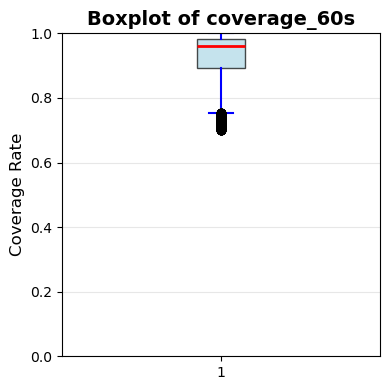

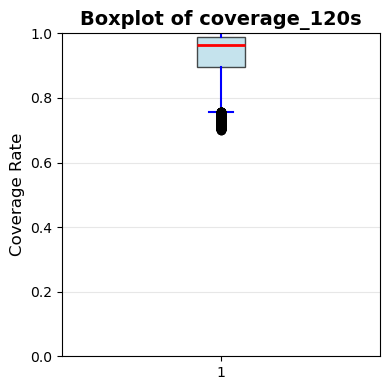

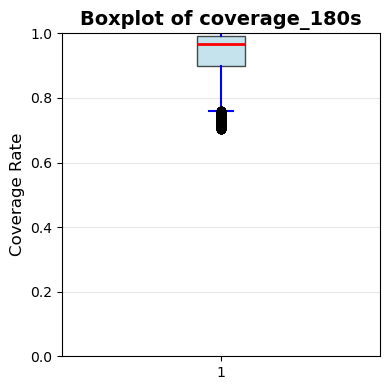

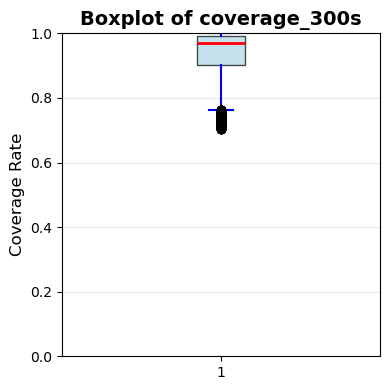

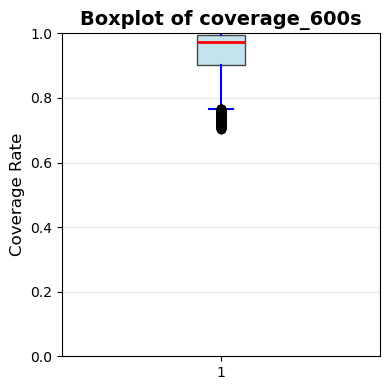

In [105]:
for col in coverage_cols:
    plt.figure(figsize=(4, 4))
    plt.boxplot(valid_summary_dic[col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='blue', linewidth=1.5),
                capprops=dict(color='blue', linewidth=1.5))
    plt.ylabel('Coverage Rate', fontsize=12)
    plt.title(f'Boxplot of {col}', fontsize=14, fontweight='bold')
    plt.ylim(0, 1)  
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
baby_id_to_indicator = {}
baby_id_to_context_size = {}

for file_path in mat_files:
    baby_id = file_path.split('/')[-1]
    
    # Load mat file
    mat_data = scipy.io.loadmat(file_path)
    
    # Get age at death
    age_at_death = mat_data['pdata'][0][-1]
    baby_id_to_indicator[baby_id] = 0 if np.isnan(age_at_death) else 1
    
    # Compute context size (time range)
    timestamps = mat_data['vt'].flatten()
    context_size = timestamps[-1] - timestamps[0]
    baby_id_to_context_size[baby_id] = context_size.item()

# Map to dataframe
valid_summary_dic['indicator_vector'] = valid_summary_dic['baby_id'].map(baby_id_to_indicator)
valid_summary_dic['context_size'] = valid_summary_dic['baby_id'].map(baby_id_to_context_size)

In [ ]:
valid_summary_dic[valid_summary_dic['indicator_vector']==0]

In [13]:
import torch
import numpy as np
import pandas as pd
from chronos import Chronos2Pipeline
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

/Users/adityagoyal/miniconda3/envs/baseline_env/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
/Users/adityagoyal/miniconda3/envs/baseline_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
with open('valid_summary_dic.pkl','rb') as f:
    valid_summary_dic = pl.load(f)
mat_file_names = valid_summary_dic['baby_id']

In [78]:
indicator_vector = list(valid_summary_dic['indicator_vector'])

In [57]:
def create_windowed_features_vectorized(mat_file_path, window_size, context_size):
    """
    Vectorized version - faster for large datasets
    """
    # Load mat file
    mat_data = scipy.io.loadmat(mat_file_path)
    vname = mat_data['vname']
    
    # Get HR and SPO2 columns
    if 'HR' in vname and 'SPO2-%' in vname:
        if (vname[0][0][0] == 'HR') and (vname[2][0][0] == 'SPO2-%'): 
            hr_cols = mat_data['vdata'][:,0]
            spo2_cols = mat_data['vdata'][:,2]
        else:
            hr_cols = mat_data['vdata'][:,vname.index('HR')]
            spo2_cols = mat_data['vdata'][:,vname.index('SPO2-%')]
    else:
        raise Exception(f"{mat_file_path}: File does not have HR or SPO2")
    
    timestamps = mat_data['vt'].flatten()
    first_timestamp = timestamps[0].item()
    
    # Calculate which window each timestamp belongs to
    window_indices = np.floor((timestamps - first_timestamp) / window_size).astype(int)
    
    # Filter to only include timestamps within context window
    context_mask = (timestamps - first_timestamp) < context_size
    window_indices = window_indices[context_mask]
    hr_cols_filtered = hr_cols[context_mask]
    spo2_cols_filtered = spo2_cols[context_mask]
    
    # Calculate number of windows
    num_windows = int(np.ceil(context_size / window_size))
    
    # Initialize arrays
    hr_windows = np.full(num_windows, np.nan)
    spo2_windows = np.full(num_windows, np.nan)
    
    # Compute average for each window
    for window_idx in range(num_windows):
        mask = window_indices == window_idx
        
        if np.any(mask):
            hr_values = hr_cols_filtered[mask]
            spo2_values = spo2_cols_filtered[mask]
            
            hr_windows[window_idx] = np.nanmean(hr_values)
            spo2_windows[window_idx] = np.nanmean(spo2_values)
    
    window_starts = first_timestamp + np.arange(num_windows) * window_size
    
    return {
        'hr_windows': hr_windows,
        'spo2_windows': spo2_windows,
        'window_starts': window_starts,
        'num_windows': num_windows,
        'window_size': window_size,
        'context_size': context_size,
        'first_timestamp': first_timestamp
    }

In [58]:
def create_embeddings(hr_data,spo2_data,pipeline):

    # Convert to tensor and add n_variates dimension
    # Shape: (1, seq_len) -> (1, 1, seq_len)
    hr_tensor = torch.tensor(hr_data, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    spo2_tensor = torch.tensor(spo2_data, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    
    # Stack into batch: (2, 1, seq_len) - 2 series, 1 variate each
    context = torch.cat([hr_tensor, spo2_tensor], dim=0)

    # Get embeddings using the pipeline's internal method
    with torch.no_grad():
        embeddings,_ = pipeline.embed(context)

    print(f"Input shape: {context.shape}")
    # print(f"Embeddings shape: {embeddings}")
    
    return embeddings
    

In [59]:


# Custom Dataset
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = [torch.FloatTensor(emb) for emb in embeddings]
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

# Simple Classifier
class SimpleClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim=128, num_classes=2):
        super(SimpleClassifier, self).__init__()
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Training function
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for embeddings, labels in dataloader:
        embeddings = embeddings.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(embeddings)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

# Validation function
def validate_epoch(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for embeddings, labels in dataloader:
            embeddings = embeddings.to(device)
            labels = labels.to(device)
            
            outputs = model(embeddings)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.0
    
    return accuracy, precision, recall, f1, auc

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        """
        Focal Loss for binary/multi-class classification
        
        Args:
            alpha: weighting factor in [0,1] to balance positive/negative examples
            gamma: focusing parameter for modulating loss (gamma >= 0)
            reduction: 'none' | 'mean' | 'sum'
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)  # probability of correct class
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [15]:
def k_fold_cross_validation(embeddings_list, labels, k=10, epochs=20, batch_size=32, 
                            learning_rate=0.01, device='cpu',use_focal_loss=True):
    """
    K-fold cross-validation - returns only average and std metrics
    
    Args:
        embeddings_list: list of embeddings
        labels: array of 0s and 1s
        k: number of folds
        epochs: training epochs per fold
        batch_size: batch size
        learning_rate: learning rate
        device: 'cpu' or 'cuda'
    
    Returns:
        avg_metrics: dict with average metrics
        std_metrics: dict with standard deviation of metrics
    """
    
    embeddings_array = np.array(embeddings_list)
    labels = np.array(labels)
    embedding_dim = embeddings_array[0].flatten().shape[0]
    
    print(f"K-Fold Cross Validation (k={k})")
    print(f"Samples: {len(labels)} | Embedding dim: {embedding_dim}")
    print(f"Class distribution: {np.bincount(labels)}\n")
    
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    fold_metrics = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(embeddings_array, labels)):
        print(f"Fold {fold + 1}/{k}...", end=" ")
        
        X_train, X_val = embeddings_array[train_idx], embeddings_array[val_idx]
        y_train, y_val = labels[train_idx], labels[val_idx]
        
        train_dataset = EmbeddingDataset(X_train, y_train)
        val_dataset = EmbeddingDataset(X_val, y_val)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        model = SimpleClassifier(embedding_dim).to(device)
        # Choose loss function
        if use_focal_loss:
            criterion = FocalLoss(alpha=0.25, gamma=2.0)  # Adjust alpha/gamma as needed
        else:
            criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        
        # Train for all epochs
        for epoch in range(epochs):
            train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Evaluate on validation set after all training is done
        val_acc, val_prec, val_rec, val_f1, val_auc = validate_epoch(model, val_loader, device)
        
        # Store metrics for this fold
        fold_metrics.append({
            'accuracy': val_acc,
            'precision': val_prec,
            'recall': val_rec,
            'f1': val_f1,
            'auc': val_auc
        })
        
        print(f"Val F1: {val_f1:.4f}, Val Acc: {val_acc:.4f}")
    
    # Calculate average and std across all folds
    avg_metrics = {metric: np.mean([fold[metric] for fold in fold_metrics]) 
                   for metric in fold_metrics[0].keys()}
    std_metrics = {metric: np.std([fold[metric] for fold in fold_metrics]) 
                   for metric in fold_metrics[0].keys()}
    
    print(f"\n{'='*60}")
    print("K-Fold Cross-Validation Results")
    print(f"{'='*60}")
    for metric in avg_metrics:
        print(f"{metric.capitalize():12s}: {avg_metrics[metric]:.4f} ± {std_metrics[metric]:.4f}")
    
    return avg_metrics, std_metrics,fold_metrics

In [16]:
# pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", 
#                                             device_map="cpu", 
#                                             dtype=torch.float32,)

In [8]:
base_dir = "/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/"
window_size = 100
context_size = 50000

embeddings_list = []

for file_name in mat_file_names:
    results = create_windowed_features_vectorized(f"{base_dir}/{file_name}", window_size, context_size)
    embeddings = create_embeddings(results['hr_windows'],results['spo2_windows'],pipeline)
    
    hr_embedding = embeddings[0][0][-1]
    spo2_embedding = embeddings[1][0][-1]
    combined_embedding = torch.cat([hr_embedding, spo2_embedding], dim=0)
    embeddings_list.append(combined_embedding.cpu().numpy())

NameError: name 'mat_file_names' is not defined

In [10]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/embeddings.pkl','rb') as f:
    embeddings_list = pl.load(f)

In [11]:
with open('/Users/adityagoyal/Desktop/Research - yin li/EDA/indicator_vector.pkl','rb') as f:
    indicator_vector = pl.load(f)

In [17]:
avg_metrics,std_metrics,fold_metrics = k_fold_cross_validation(embeddings_list, indicator_vector, k=5, epochs=50, batch_size=32, 
                            learning_rate=0.01, device='cpu')

K-Fold Cross Validation (k=5)
Samples: 5997 | Embedding dim: 1536
Class distribution: [5712  285]



ValueError: Found input variables with inconsistent numbers of samples: [5027, 5997]

In [ ]:
# (batch_size, context_length, d_model)

In [107]:
with open('fold_metrics_1','wb') as f:
    pl.dump(fold_metrics,f)

In [29]:
with open('valid_summary_dic.pkl','rb') as f:
    summary_df = pl.load(f)

In [32]:
summary_df

,baby_id,coverage_60s,hits_60s,total_windows_60s,coverage_120s,hits_120s,total_windows_120s,coverage_180s,hits_180s,total_windows_180s,coverage_300s,hits_300s,total_windows_300s,coverage_600s,hits_600s,total_windows_600s,indicator_vector,context_size
0,NICU_6626_vitals.mat,0.956858,1486,1553,0.972973,756,777,0.984556,510,518,0.993569,309,311,1.000000,156,156,0,93126.0
1,NICU_1972_vitals.mat,0.875924,43840,50050,0.877283,21954,25025,0.878386,14655,16684,0.878721,8796,10010,0.879520,4402,5005,0,3002958.0
2,NICU_6339_vitals.mat,0.976284,24658,25257,0.982263,12405,12629,0.985153,8294,8419,0.987332,4988,5052,0.990103,2501,2526,0,1515368.0
4,NICU_3639_vitals.mat,0.981040,9003,9177,0.988233,4535,4589,0.989539,3027,3059,0.990196,1818,1836,0.994553,913,918,0,550616.0
6,NICU_7358_vitals.mat,0.952352,17109,17965,0.959368,8618,8983,0.961930,5761,5989,0.965488,3469,3593,0.969393,1742,1797,0,1077868.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5952,NICU_8710_vitals.mat,0.946261,13083,13826,0.952409,6584,6913,0.955956,4406,4609,0.958424,2651,2766,0.959508,1327,1383,0,829550.0
5953,NICU_5244_vitals.mat,0.964761,50786,52641,0.968618,25495,26321,0.969909,17019,17547,0.971602,10230,10529,0.973409,5125,5265,0,3158426.0
5954,NICU_4058_vitals.mat,0.994286,22448,22577,0.997874,11265,11289,0.998538,7515,7526,0.998893,4511,4516,0.999557,2257,2258,0,1354616.0
5956,NICU_4225_vitals.mat,0.991550,7862,7929,0.993947,3941,3965,0.994703,2629,2643,0.995586,1579,1586,0.996217,790,793,0,475698.0


In [59]:
mat_file = scipy.io.loadmat(f"/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/NICU_6626_vitals.mat")

In [60]:
baby_ids = summary_df['baby_id']

In [ ]:
gest_age_files = [scipy.io.loadmat(f"/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/{fid}")['pdata'][0][3]  for fid in baby_ids]
gest_age_days_files = [scipy.io.loadmat(f"/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/{fid}")['pdata'][0][4]  for fid in baby_ids]

In [62]:
birth_weight_files = [scipy.io.loadmat(f"/Users/adityagoyal/Desktop/Research - yin li/EDA/data/download/Vitals/{fid}")['pdata'][0][2]  for fid in baby_ids]

In [65]:
with open('birth_weight_files.pkl','wb') as f:
    pl.dump(birth_weight_files,f)

In [55]:
with open('valid_gest_age_files.pkl','wb') as f:
    pl.dump(gest_age_files,f)

In [56]:
with open('valid_gest_age_days_files.pkl','wb') as f:
    pl.dump(gest_age_days_files,f)

In [108]:
birth_weight_files_arr = [  (age == None or np.isnan(age))  for age in birth_weight_files ]
gest_age_files_arr = [ (age == None or np.isnan(age))  for age in gest_age_files ]
gest_age_days_files_arr = [ (age == None or np.isnan(age))  for age in gest_age_days_files ]

In [109]:
print(  float(sum(gest_age_files_arr)) / len(gest_age_files_arr)   )
print(  float(sum(gest_age_days_files_arr)) / len(gest_age_days_files_arr)      )
print(   float(sum(birth_weight_files_arr))  /  len(birth_weight_files_arr)     )

0.0005967774020290431
0.24030236721702805
0.002188183807439825


In [110]:
indicator_vector = list(summary_df['indicator_vector'])

## seeing if there is any signifcant statistical differecne between the perished NICU children and those who didnt perosh

In [122]:
sume_1 = 0.0
valid_label_1 = 0
arr_1 = []
for i in range(len(birth_weight_files)):
    if(indicator_vector[i]==1) and (birth_weight_files_arr[i] == 0):
        sume_1 += birth_weight_files[i]
        valid_label_1+=1
        arr_1.append(birth_weight_files[i])

In [123]:
sume_0 = 0.0
valid_label_0 = 0
arr_0 = []
for i in range(len(birth_weight_files)):
    if(indicator_vector[i]==0) and (birth_weight_files_arr[i] == 0):
        sume_0 += birth_weight_files[i]
        valid_label_0 += 1
        arr_0.append(birth_weight_files[i])

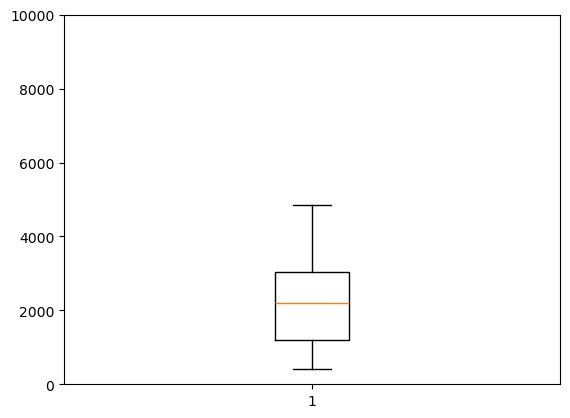

In [129]:
plt.boxplot(arr_1)
plt.ylim(0, 10000)
plt.show()

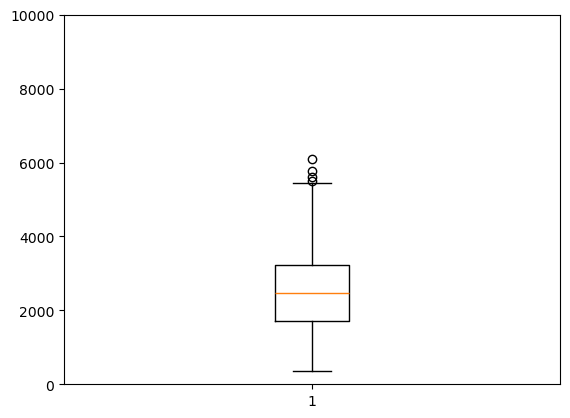

In [130]:
plt.boxplot(arr_0)
plt.ylim(0, 10000)
plt.show()